This Project is an analysis of the Mens Tennis Tournament From 2000 - 2025 and
using Random Forest and Deep Neural Networks to make the predictions for the
Winner. This project uses stacking to join multiple methods together for this
analysis.
It uses Supervised Machine Learning Technique taught to solve this issue.

In [ ]:
import pandas as pd
import numpy as np
import glob
import os

excel_files = []

# Get a list of all files in the current directory that are excel files
all_excel_files = glob.glob('*.xls') + glob.glob('*.xlsx')

# Iterate through each file and check for the 'year' naming convention
for file_path in all_excel_files:
    filename = os.path.basename(file_path)
    # Split filename and extension
    name, ext = os.path.splitext(filename)

    # Check if the name consists solely of digits (representing a year)
    if name.isdigit():
        excel_files.append(file_path)

print("Identified Excel files following the 'year.xls' or 'year.xlsx' naming convention:")
for file in excel_files:
    print(file)

all_dfs = []

for file_path in excel_files:
    # Extract year from filename
    filename = os.path.basename(file_path)
    name, _ = os.path.splitext(filename)
    year = int(name)

    # Read the Excel file into a DataFrame
    df = pd.read_excel(file_path)

    # Add a 'Year' column
    df['Year'] = year

    # Append the DataFrame to the list
    all_dfs.append(df)

# Combine all DataFrames into a single master DataFrame
combined_df = pd.concat(all_dfs, ignore_index=True)

print("Successfully loaded and combined all Excel files.")

Identified Excel files following the 'year.xls' or 'year.xlsx' naming convention:
2001.xls
2009.xls
2004.xls
2010.xls
2011.xls
2012.xls
2006.xls
2003.xls
2008.xls
2002.xls
2005.xls
2007.xls
2000.xls
2019.xlsx
2020.xlsx
2023.xlsx
2021.xlsx
2014.xlsx
2015.xlsx
2013.xlsx
2018.xlsx
2025.xlsx
2017.xlsx
2022.xlsx
2016.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Successfully loaded and combined all Excel files.


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [ ]:
selected_columns = [
    'Date', 'Year', 'Tournament', 'Surface', 'Winner', 'Loser',
    'WRank', 'LRank', 'Wsets', 'Lsets', 'Best of',
    'B365W', 'B365L', 'PSW', 'PSL', 'MaxW', 'MaxL', 'AvgW', 'AvgL'
]

# Create a new DataFrame with only the selected columns
processed_df = combined_df[selected_columns].copy()

print("Selected columns for preprocessing.")
print("Shape of the new DataFrame:", processed_df.shape)

processed_df['WRank'] = pd.to_numeric(processed_df['WRank'], errors='coerce')
processed_df['LRank'] = pd.to_numeric(processed_df['LRank'], errors='coerce')

print("Converted 'WRank' and 'LRank' to numeric, handling non-numeric values.")
print(processed_df[['WRank', 'LRank']].info())

Selected columns for preprocessing.
Shape of the new DataFrame: (66643, 19)
Converted 'WRank' and 'LRank' to numeric, handling non-numeric values.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66643 entries, 0 to 66642
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   WRank   66620 non-null  float64
 1   LRank   66501 non-null  float64
dtypes: float64(2)
memory usage: 1.0 MB
None


In [ ]:
initial_rows = processed_df.shape[0]
processed_df.dropna(subset=['WRank', 'LRank', 'Wsets', 'Lsets', 'Best of'], inplace=True)

print(f"Dropped rows with missing critical values. Original rows: {initial_rows}, New rows: {processed_df.shape[0]}")
print("Current non-null counts for critical columns:")
print(processed_df[['WRank', 'LRank', 'Wsets', 'Lsets', 'Best of']].isnull().sum())
betting_odds_columns = [
    'B365W', 'B365L', 'PSW', 'PSL', 'MaxW', 'MaxL', 'AvgW', 'AvgL'
]

for col in betting_odds_columns:
    if processed_df[col].isnull().any():
        mean_val = processed_df[col].mean()
        processed_df[col].fillna(mean_val, inplace=True)
        print(f"Imputed missing values in '{col}' with its mean ({mean_val:.2f}).")
    else:
        print(f"No missing values found in '{col}'.")

print("\nSummary of betting odds columns after imputation:")
print(processed_df[betting_odds_columns].isnull().sum())


winner_df = processed_df.copy()
loser_df = processed_df.copy()

# Prepare winner's perspective
winner_df['Target'] = 1
winner_df = winner_df.rename(columns={
    'Winner': 'Player',
    'Loser': 'Opponent',
    'WRank': 'PlayerRank',
    'LRank': 'OpponentRank',
    'Wsets': 'PlayerSets',
    'Lsets': 'OpponentSets',
    'B365W': 'PlayerOdds_B365',
    'B365L': 'OpponentOdds_B365',
    'PSW': 'PlayerOdds_PS',
    'PSL': 'OpponentOdds_PS',
    'MaxW': 'PlayerOdds_Max',
    'MaxL': 'OpponentOdds_Max',
    'AvgW': 'PlayerOdds_Avg',
    'AvgL': 'OpponentOdds_Avg'
})

# Prepare loser's perspective
loser_df['Target'] = 0
loser_df = loser_df.rename(columns={
    'Loser': 'Player',
    'Winner': 'Opponent',
    'LRank': 'PlayerRank',
    'WRank': 'OpponentRank',
    'Lsets': 'PlayerSets',
    'Wsets': 'OpponentSets',
    'B365L': 'PlayerOdds_B365',
    'B365W': 'OpponentOdds_B365',
    'PSL': 'PlayerOdds_PS',
    'PSW': 'OpponentOdds_PS',
    'MaxL': 'PlayerOdds_Max',
    'MaxW': 'OpponentOdds_Max',
    'AvgL': 'PlayerOdds_Avg',
    'AvgW': 'OpponentOdds_Avg'
})

# Select and reorder columns for consistency
common_columns = [
    'Date', 'Year', 'Tournament', 'Surface', 'Best of', 'Player', 'Opponent',
    'PlayerRank', 'OpponentRank', 'PlayerSets', 'OpponentSets',
    'PlayerOdds_B365', 'OpponentOdds_B365',
    'PlayerOdds_PS', 'OpponentOdds_PS',
    'PlayerOdds_Max', 'OpponentOdds_Max',
    'PlayerOdds_Avg', 'OpponentOdds_Avg', 'Target'
]

winner_df = winner_df[common_columns]
loser_df = loser_df[common_columns]

# Concatenate the two DataFrames
player_df = pd.concat([winner_df, loser_df], ignore_index=True)

print("Created player-centric DataFrame `player_df`.")
print("Shape of `player_df`:", player_df.shape)
print("First 5 rows of `player_df` from winner's perspective:")
display(player_df[player_df['Target'] == 1].head())
print("First 5 rows of `player_df` from loser's perspective:")
display(player_df[player_df['Target'] == 0].head())

Dropped rows with missing critical values. Original rows: 66643, New rows: 66131
Current non-null counts for critical columns:
WRank      0
LRank      0
Wsets      0
Lsets      0
Best of    0
dtype: int64
Imputed missing values in 'B365W' with its mean (1.83).
Imputed missing values in 'B365L' with its mean (3.48).
Imputed missing values in 'PSW' with its mean (1.93).
Imputed missing values in 'PSL' with its mean (4.01).
Imputed missing values in 'MaxW' with its mean (2.00).
Imputed missing values in 'MaxL' with its mean (6.59).
Imputed missing values in 'AvgW' with its mean (1.85).
Imputed missing values in 'AvgL' with its mean (3.45).

Summary of betting odds columns after imputation:
B365W    0
B365L    0
PSW      0
PSL      0
MaxW     0
MaxL     0
AvgW     0
AvgL     0
dtype: int64
Created player-centric DataFrame `player_df`.
Shape of `player_df`: (132262, 20)
First 5 rows of `player_df` from winner's perspective:


/tmp/ipython-input-1782022546.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  processed_df[col].fillna(mean_val, inplace=True)


,Date,Year,Tournament,Surface,Best of,Player,Opponent,PlayerRank,OpponentRank,PlayerSets,OpponentSets,PlayerOdds_B365,OpponentOdds_B365,PlayerOdds_PS,OpponentOdds_PS,PlayerOdds_Max,OpponentOdds_Max,PlayerOdds_Avg,OpponentOdds_Avg,Target
0,2001-01-01,2001,AAPT Championships,Hard,3.0,Clement A.,Gaudenzi A.,18.0,101.0,2.0,1.0,1.834385,3.477294,1.926705,4.005395,1.996491,6.591163,1.849846,3.447275,1
1,2001-01-01,2001,AAPT Championships,Hard,3.0,Goldstein P.,Jones A.,81.0,442.0,2.0,0.0,1.834385,3.477294,1.926705,4.005395,1.996491,6.591163,1.849846,3.447275,1
2,2001-01-01,2001,AAPT Championships,Hard,3.0,Haas T.,Smith L.,23.0,485.0,2.0,0.0,1.834385,3.477294,1.926705,4.005395,1.996491,6.591163,1.849846,3.447275,1
3,2001-01-01,2001,AAPT Championships,Hard,3.0,Henman T.,Rusedski G.,10.0,69.0,2.0,0.0,1.834385,3.477294,1.926705,4.005395,1.996491,6.591163,1.849846,3.447275,1
4,2001-01-01,2001,AAPT Championships,Hard,3.0,Hewitt L.,Arthurs W.,7.0,83.0,2.0,0.0,1.834385,3.477294,1.926705,4.005395,1.996491,6.591163,1.849846,3.447275,1


First 5 rows of `player_df` from loser's perspective:


,Date,Year,Tournament,Surface,Best of,Player,Opponent,PlayerRank,OpponentRank,PlayerSets,OpponentSets,PlayerOdds_B365,OpponentOdds_B365,PlayerOdds_PS,OpponentOdds_PS,PlayerOdds_Max,OpponentOdds_Max,PlayerOdds_Avg,OpponentOdds_Avg,Target
66131,2001-01-01,2001,AAPT Championships,Hard,3.0,Gaudenzi A.,Clement A.,101.0,18.0,1.0,2.0,3.477294,1.834385,4.005395,1.926705,6.591163,1.996491,3.447275,1.849846,0
66132,2001-01-01,2001,AAPT Championships,Hard,3.0,Jones A.,Goldstein P.,442.0,81.0,0.0,2.0,3.477294,1.834385,4.005395,1.926705,6.591163,1.996491,3.447275,1.849846,0
66133,2001-01-01,2001,AAPT Championships,Hard,3.0,Smith L.,Haas T.,485.0,23.0,0.0,2.0,3.477294,1.834385,4.005395,1.926705,6.591163,1.996491,3.447275,1.849846,0
66134,2001-01-01,2001,AAPT Championships,Hard,3.0,Rusedski G.,Henman T.,69.0,10.0,0.0,2.0,3.477294,1.834385,4.005395,1.926705,6.591163,1.996491,3.447275,1.849846,0
66135,2001-01-01,2001,AAPT Championships,Hard,3.0,Arthurs W.,Hewitt L.,83.0,7.0,0.0,2.0,3.477294,1.834385,4.005395,1.926705,6.591163,1.996491,3.447275,1.849846,0


### Feature Engineering Explanation

In this section, new features were created from existing ones to provide the models with more insightful information. These engineered features aim to capture relationships and patterns that might not be directly apparent from the raw data. The following features were created:

1.  **`RankDifference`**: This feature is calculated as `PlayerRank - OpponentRank`. It directly measures the difference in ranking between the player and their opponent. A positive value indicates the player has a higher rank (numerically lower, i.e., better) than the opponent, while a negative value suggests the opposite. This is a crucial indicator of a player's perceived strength relative to their opponent.

2.  **`RankRatio`**: Calculated as `PlayerRank / OpponentRank`. This provides a ratio of the player's rank to the opponent's rank. It was handled carefully to avoid division by zero by replacing `OpponentRank` of 0 with `NaN` and then filling `NaN` results with 0. This feature offers another perspective on the relative ranking, emphasizing proportional differences. A ratio less than 1 suggests the player has a better rank, and a ratio greater than 1 suggests a worse rank.

3.  **Odds Ratios (`B365OddsRatio`, `PSOddsRatio`, `MaxOddsRatio`, `AvgOddsRatio`)**: These features are calculated by dividing the Player's Odds by the Opponent's Odds from different betting agencies (B365, Pinnacle Sports (PS), Max odds, and Average odds). For example, `B365OddsRatio = PlayerOdds_B365 / OpponentOdds_B365`. These ratios are vital for capturing the market's perception of a player's winning probability relative to their opponent. A lower odds ratio for the player generally indicates they are favored to win by the betting market, suggesting a higher implied probability of winning.

In [ ]:
import numpy as np

# Calculate RankDifference
player_df['RankDifference'] = player_df['PlayerRank'] - player_df['OpponentRank']

# Calculate RankRatio, handling potential division by zero
# Replace 0s in OpponentRank with NaN to avoid division by zero errors
player_df['OpponentRank_cleaned'] = player_df['OpponentRank'].replace(0, np.nan)
player_df['RankRatio'] = player_df['PlayerRank'] / player_df['OpponentRank_cleaned']
player_df['RankRatio'].fillna(0, inplace=True) # Fill NaN (from division by zero) with 0

# Calculate various Odds Ratios
player_df['B365OddsRatio'] = player_df['PlayerOdds_B365'] / player_df['OpponentOdds_B365']
player_df['PSOddsRatio'] = player_df['PlayerOdds_PS'] / player_df['OpponentOdds_PS']
player_df['MaxOddsRatio'] = player_df['PlayerOdds_Max'] / player_df['OpponentOdds_Max']
player_df['AvgOddsRatio'] = player_df['PlayerOdds_Avg'] / player_df['OpponentOdds_Avg']

# Drop the temporary cleaned column
player_df.drop(columns=['OpponentRank_cleaned'], inplace=True)

print("Created new features in player_df: RankDifference, RankRatio, and various odds ratios.")
print("First 5 rows with new features:")
display(player_df.head())

Created new features in player_df: RankDifference, RankRatio, and various odds ratios.
First 5 rows with new features:


/tmp/ipython-input-1040330268.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  player_df['RankRatio'].fillna(0, inplace=True) # Fill NaN (from division by zero) with 0


,Date,Year,Tournament,Surface,Best of,Player,Opponent,PlayerRank,OpponentRank,PlayerSets,...,OpponentOdds_Max,PlayerOdds_Avg,OpponentOdds_Avg,Target,RankDifference,RankRatio,B365OddsRatio,PSOddsRatio,MaxOddsRatio,AvgOddsRatio
0,2001-01-01,2001,AAPT Championships,Hard,3.0,Clement A.,Gaudenzi A.,18.0,101.0,2.0,...,6.591163,1.849846,3.447275,1,-83.0,0.178218,0.527532,0.481027,0.302904,0.536611
1,2001-01-01,2001,AAPT Championships,Hard,3.0,Goldstein P.,Jones A.,81.0,442.0,2.0,...,6.591163,1.849846,3.447275,1,-361.0,0.183258,0.527532,0.481027,0.302904,0.536611
2,2001-01-01,2001,AAPT Championships,Hard,3.0,Haas T.,Smith L.,23.0,485.0,2.0,...,6.591163,1.849846,3.447275,1,-462.0,0.047423,0.527532,0.481027,0.302904,0.536611
3,2001-01-01,2001,AAPT Championships,Hard,3.0,Henman T.,Rusedski G.,10.0,69.0,2.0,...,6.591163,1.849846,3.447275,1,-59.0,0.144928,0.527532,0.481027,0.302904,0.536611
4,2001-01-01,2001,AAPT Championships,Hard,3.0,Hewitt L.,Arthurs W.,7.0,83.0,2.0,...,6.591163,1.849846,3.447275,1,-76.0,0.084337,0.527532,0.481027,0.302904,0.536611


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define feature matrix X and target vector y
X = player_df.drop(columns=['Date', 'Player', 'Opponent', 'Target', 'PlayerSets', 'OpponentSets'])
y = player_df['Target']

print("Defined feature matrix X and target vector y.")

# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=['Surface', 'Tournament'], drop_first=True)

print("Applied one-hot encoding to 'Surface' and 'Tournament'.")

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Split data into training and testing sets.")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

# Identify numerical columns for scaling
numerical_cols = [
    'Year', 'Best of', 'PlayerRank', 'OpponentRank', 'RankDifference', 'RankRatio',
    'PlayerOdds_B365', 'OpponentOdds_B365', 'PlayerOdds_PS', 'OpponentOdds_PS',
    'PlayerOdds_Max', 'OpponentOdds_Max', 'PlayerOdds_Avg', 'OpponentOdds_Avg',
    'B365OddsRatio', 'PSOddsRatio', 'MaxOddsRatio', 'AvgOddsRatio'
]

# Filter for columns that actually exist in X (after one-hot encoding some might be gone/transformed)
numerical_cols_present = [col for col in numerical_cols if col in X_train.columns]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on X_train numerical columns and transform both X_train and X_test
X_train[numerical_cols_present] = scaler.fit_transform(X_train[numerical_cols_present])
X_test[numerical_cols_present] = scaler.transform(X_test[numerical_cols_present])

print("Scaled numerical features using StandardScaler.")
print("First 5 rows of X_train after scaling and encoding:")
display(X_train.head())

Defined feature matrix X and target vector y.
Applied one-hot encoding to 'Surface' and 'Tournament'.
Split data into training and testing sets.
X_train shape: (105809, 288), X_test shape: (26453, 288)
Scaled numerical features using StandardScaler.
First 5 rows of X_train after scaling and encoding:


,Year,Best of,PlayerRank,OpponentRank,PlayerOdds_B365,OpponentOdds_B365,PlayerOdds_PS,OpponentOdds_PS,PlayerOdds_Max,OpponentOdds_Max,...,Tournament_Western & Southern Financial Group Masters,Tournament_Wimbledon,Tournament_Winston-Salem Open at Wake Forest University,Tournament_Zhuhai Championships,Tournament_Zhuhai Open,Tournament_adidas International,Tournament_adidas Open,Tournament_bet-at-home Open,Tournament_bett1HULKS Championship,Tournament_bett1HULKS Indoors
4517,-0.352019,2.065548,-0.712286,0.305327,-0.655748,4.947560,-0.300287,0.300140,-0.015807,0.011618,...,False,True,False,False,False,False,False,False,False,False
80427,0.058480,-0.484133,-0.503819,0.426112,-0.417486,-0.181767,-0.356815,-0.215199,-0.017842,-0.011408,...,False,False,False,False,False,False,False,False,False,False
10063,-0.215186,2.065548,0.528588,1.825204,-0.262616,-0.374117,-0.287846,-0.293132,-0.014788,-0.013580,...,False,True,False,False,False,False,False,False,False,False
31797,-0.625685,-0.484133,-0.533600,-0.238205,-0.115689,-0.434226,-0.204507,-0.355190,-0.015807,0.011618,...,False,False,False,False,False,False,False,False,False,False
55853,1.837310,2.065548,-0.414476,-0.238205,-0.516762,0.218961,-0.445901,0.041692,-0.019980,-0.006793,...,False,False,False,False,False,False,False,False,False,False


### Random Forest Classifier

**Random Forest** is an ensemble learning method for classification (and regression) that operates by constructing a multitude of decision trees during training. For classification tasks, the output of the random forest is the class selected by most trees.

Here's a breakdown of the code:

1.  **`from sklearn.ensemble import RandomForestClassifier`**:
    *   This line imports the `RandomForestClassifier` class from scikit-learn's `ensemble` module. Scikit-learn is a popular machine learning library in Python.

2.  **`rf_classifier = RandomForestClassifier(random_state=42)`**:
    *   An instance of `RandomForestClassifier` is created. `random_state=42` is set to ensure reproducibility of results. If you run the code multiple times with the same `random_state`, you'll get the same split and model training.

3.  **`rf_classifier.fit(X_train, y_train)`**:
    *   This is the training step. The `fit` method trains the Random Forest model using the training data (`X_train` for features and `y_train` for the target variable).

4.  **`y_pred_rf = rf_classifier.predict(X_test)`**:
    *   After training, the `predict` method is used to make predictions on the unseen test data (`X_test`). These predictions (`y_pred_rf`) will be the model's classifications (0 or 1 in this binary classification case) for each sample in the test set.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate RandomForestClassifier with a random state for reproducibility
rf_classifier = RandomForestClassifier(random_state=42)

# Train the classifier using the training data
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

y_pred_rf = rf_classifier.predict(X_test)

print("Predictions on the test set generated.")
print("First 10 predictions:", y_pred_rf[:10])

Random Forest Classifier trained successfully.
Predictions on the test set generated.
First 10 predictions: [1 0 0 1 1 1 1 0 1 1]


Evaluate Random Forest Classifier


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)

print(f"Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Extract feature importances
feature_importances = rf_classifier.feature_importances_

# Create a Series for feature importances with feature names
feature_importance_series = pd.Series(feature_importances, index=X_train.columns)

# Sort feature importances in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

print("\nTop 10 Most Important Features:")
print(sorted_feature_importances.head(10))

Random Forest Classifier Performance:
Accuracy: 0.8233
Precision: 0.8269
Recall: 0.8198

Top 10 Most Important Features:
MaxOddsRatio        0.098542
AvgOddsRatio        0.095522
PlayerOdds_Avg      0.094791
OpponentOdds_Avg    0.082029
OpponentOdds_Max    0.080381
PlayerOdds_Max      0.080333
PSOddsRatio         0.061700
PlayerOdds_PS       0.045931
OpponentOdds_PS     0.040825
RankRatio           0.034402
dtype: float64


### Hyperparameter Tuning with GridSearchCV

To improve the performance and prevent overfitting of the Random Forest model, we will perform hyperparameter tuning. `GridSearchCV` systematically works through multiple combinations of parameter tunes, cross-validating as it goes to determine which tunings work best. We'll focus on key parameters such as `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_features`.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200], # Number of trees in the forest
    'max_depth': [10, 20, None], # Maximum depth of the tree
    'min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2], # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2'] # Number of features to consider when looking for the best split
}

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
# verbose=2 will show progress during the search
# n_jobs=-1 will use all available CPU cores
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

print("Starting GridSearchCV for hyperparameter tuning...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters found: {best_params}")
print(f"Best Cross-validation Accuracy: {best_score:.4f}")

# Use the best estimator to make predictions on the test set
best_rf_classifier = grid_search.best_estimator_
y_pred_rf_tuned = best_rf_classifier.predict(X_test)

print("Predictions on the test set using the tuned model generated.")


Starting GridSearchCV for hyperparameter tuning...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
GridSearchCV completed.
Best Parameters found: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-validation Accuracy: 0.8315
Predictions on the test set using the tuned model generated.


### Evaluate Tuned Random Forest Classifier


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Calculate evaluation metrics for the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_tuned = precision_score(y_test, y_pred_rf_tuned)
recall_tuned = recall_score(y_test, y_pred_rf_tuned)

print(f"Tuned Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")

# Compare with the initial model's performance (assuming `accuracy`, `precision`, `recall` variables exist)
print("\nComparison with initial model:")
print(f"Initial Accuracy: {accuracy:.4f} -> Tuned Accuracy: {accuracy_tuned:.4f}")
print(f"Initial Precision: {precision:.4f} -> Tuned Precision: {precision_tuned:.4f}")
print(f"Initial Recall: {recall:.4f} -> Tuned Recall: {recall_tuned:.4f}")

# Extract feature importances from the tuned model
feature_importances_tuned = best_rf_classifier.feature_importances_
feature_importance_series_tuned = pd.Series(feature_importances_tuned, index=X_train.columns)
sorted_feature_importances_tuned = feature_importance_series_tuned.sort_values(ascending=False)

print("\nTop 10 Most Important Features (Tuned Model):")
display(sorted_feature_importances_tuned.head(10))


Tuned Random Forest Classifier Performance:
Accuracy: 0.8299
Precision: 0.8303
Recall: 0.8310

Comparison with initial model:
Initial Accuracy: 0.8233 -> Tuned Accuracy: 0.8299
Initial Precision: 0.8269 -> Tuned Precision: 0.8303
Initial Recall: 0.8198 -> Tuned Recall: 0.8310

Top 10 Most Important Features (Tuned Model):


,0
PlayerOdds_Avg,0.124987
MaxOddsRatio,0.121286
OpponentOdds_Avg,0.120967
OpponentOdds_Max,0.113992
PlayerOdds_Max,0.104076
AvgOddsRatio,0.102037
PSOddsRatio,0.074308
PlayerOdds_PS,0.056166
OpponentOdds_PS,0.045098
OpponentOdds_B365,0.038136


In [ ]:
display(sorted_feature_importances_tuned.head(10))

,0
PlayerOdds_Avg,0.124987
MaxOddsRatio,0.121286
OpponentOdds_Avg,0.120967
OpponentOdds_Max,0.113992
PlayerOdds_Max,0.104076
AvgOddsRatio,0.102037
PSOddsRatio,0.074308
PlayerOdds_PS,0.056166
OpponentOdds_PS,0.045098
OpponentOdds_B365,0.038136


## Define and Train Deep Neural Network
Define a Deep Neural Network (DNN) architecture using Keras or TensorFlow, compile it, and train it using the `X_train` and `y_train` datasets. Consider a simple multi-layer perceptron for the initial setup.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the DNN model architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer
    Dense(64, activation='relu'), # Hidden layer 1
    Dense(32, activation='relu'), # Hidden layer 2
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Deep Neural Network model defined and compiled.")
model.summary()

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

print("\nDeep Neural Network model trained successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Deep Neural Network model defined and compiled.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,361 (185.00 KB)

 Trainable params: 47,361 (185.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7230 - loss: nan - val_accuracy: 0.4992 - val_loss: nan
Epoch 2/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.4979 - loss: nan - val_accuracy: 0.4992 - val_loss: nan
Epoch 3/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5018 - loss: nan - val_accuracy: 0.4992 - val_loss: nan
Epoch 4/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5026 - loss: nan - val_accuracy: 0.4992 - val_loss: nan
Epoch 5/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5006 - loss: nan - val_accuracy: 0.4992 - val_loss: nan
Epoch 6/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5042 - loss: nan - val_accuracy: 0.4992 - val_loss: nan
Epoch 7/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5025 - loss: nan - val_accuracy: 0.4992 - val_loss: nan
Epoch 8/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5015 - loss: nan - val_accuracy: 0.4992 - val_loss: nan
Epoch 9

## Evaluate Deep Neural Network

Evaluate the trained Deep Neural Network's performance on the `X_test` and `y_test` datasets, calculating metrics such as accuracy, precision, and recall. This will provide a baseline for the DNN's individual performance.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 1. Use the trained Deep Neural Network model (`model`) to predict probabilities on the `X_test` dataset.
y_pred_dnn_prob = model.predict(X_test)

# 2. Convert the predicted probabilities (`y_pred_dnn_prob`) into binary predictions (0 or 1)
# by applying a threshold of 0.5.
y_pred_dnn = (y_pred_dnn_prob > 0.5).astype(int)

# 3. Calculate the accuracy, precision, and recall scores of the Deep Neural Network
accuracy_dnn = accuracy_score(y_test, y_pred_dnn)
precision_dnn = precision_score(y_test, y_pred_dnn)
recall_dnn = recall_score(y_test, y_pred_dnn)

# 4. Print the calculated accuracy, precision, and recall scores for the Deep Neural Network.
print(f"Deep Neural Network Performance:")
print(f"Accuracy: {accuracy_dnn:.4f}")
print(f"Precision: {precision_dnn:.4f}")
print(f"Recall: {recall_dnn:.4f}")

827/827 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Deep Neural Network Performance:
Accuracy: 0.4979
Precision: 0.0000
Recall: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Ensure no NaN values remain in X_train and X_test before training
# Fill NaNs in X_train with its column means
X_train = X_train.fillna(X_train.mean())
# Fill NaNs in X_test with the means calculated from X_train to prevent data leakage
X_test = X_test.fillna(X_train.mean())

print("Filled any remaining NaN values in X_train and X_test.")

# Define the DNN model architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer
    Dense(64, activation='relu'), # Hidden layer 1
    Dense(32, activation='relu'), # Hidden layer 2
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Deep Neural Network model defined and compiled.")
model.summary()

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

print("\nDeep Neural Network model trained successfully.")

Filled any remaining NaN values in X_train and X_test.
Deep Neural Network model defined and compiled.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,361 (185.00 KB)

 Trainable params: 47,361 (185.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8173 - loss: 0.3730 - val_accuracy: 0.8320 - val_loss: 0.3252
Epoch 2/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8296 - loss: 0.3226 - val_accuracy: 0.8303 - val_loss: 0.3227
Epoch 3/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8326 - loss: 0.3165 - val_accuracy: 0.8295 - val_loss: 0.3197
Epoch 4/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8311 - loss: 0.3150 - val_accuracy: 0.8304 - val_loss: 0.3195
Epoch 5/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8309 - loss: 0.3148 - val_accuracy: 0.8274 - val_loss: 0.3199
Epoch 6/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8305 - loss: 0.3159 - val_accuracy: 0.8272 - val_loss: 0.3182
Epoch 7/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8314 - loss: 0.3144 - val_accuracy: 0.8299 - val_loss: 0.3189
Epoch 8/10
1323/1323 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8322 - loss: 0.3131 

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 1. Use the trained Deep Neural Network model (`model`) to predict probabilities on the `X_test` dataset.
y_pred_dnn_prob = model.predict(X_test)

# 2. Convert the predicted probabilities (`y_pred_dnn_prob`) into binary predictions (0 or 1)
# by applying a threshold of 0.5.
y_pred_dnn = (y_pred_dnn_prob > 0.5).astype(int)

# 3. Calculate the accuracy, precision, and recall scores of the Deep Neural Network
accuracy_dnn = accuracy_score(y_test, y_pred_dnn)
precision_dnn = precision_score(y_test, y_pred_dnn)
recall_dnn = recall_score(y_test, y_pred_dnn)

# 4. Print the calculated accuracy, precision, and recall scores for the Deep Neural Network.
print(f"Deep Neural Network Performance:")
print(f"Accuracy: {accuracy_dnn:.4f}")
print(f"Precision: {precision_dnn:.4f}")
print(f"Recall: {recall_dnn:.4f}")

827/827 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Deep Neural Network Performance:
Accuracy: 0.8242
Precision: 0.8096
Recall: 0.8497


## Implement Hybrid Model (Stacking)

Implement a hybrid model using a stacking approach. This will involve using the predictions from the tuned Random Forest Classifier and the Deep Neural Network as input features for a meta-learner. Train the meta-learner on a subset of the training data or using cross-validation to combine the base model predictions.


In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.base import BaseEstimator, ClassifierMixin, clone
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Wrapper for Keras model to be compatible with StackingClassifier
class KerasClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, input_shape=None, epochs=10, batch_size=64, random_state=42):
        # Store parameters that define the model or training process
        self.input_shape = input_shape
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.model = None # The actual compiled and fitted Keras model

    def fit(self, X, y):
        # Set a fixed seed for reproducibility within each fit call for Keras model initialization
        tf.random.set_seed(self.random_state)
        np.random.seed(self.random_state)

        # If `model` is None, it means we need to build it (e.g., after cloning).
        if self.model is None:
            # Rebuild and compile the model for this cloned instance
            self.model = Sequential([
                Dense(128, activation='relu', input_shape=(self.input_shape,)),
                Dense(64, activation='relu'),
                Dense(32, activation='relu'),
                Dense(1, activation='sigmoid')
            ])
            self.model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        # Train the model
        # Use X and y directly for fitting within StackingClassifier's CV
        self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=0)

        # Set the classes_ attribute required by scikit-learn estimators
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        if self.model is None:
            raise ValueError("Model has not been fitted yet.")
        # Keras model.predict returns probabilities for binary classification
        predictions = self.model.predict(X, verbose=0).ravel()
        # StackingClassifier expects (n_samples, n_classes), so for binary, (n_samples, 2)
        # We need to return probabilities for both classes [P(class 0), P(class 1)]
        return np.vstack([1 - predictions, predictions]).T

    def predict(self, X):
        probabilities = self.predict_proba(X)[:, 1]
        return (probabilities > 0.5).astype(int)

# Initialize KerasClassifierWrapper with parameters for model building and training
keras_base_model = KerasClassifierWrapper(input_shape=X_train.shape[1], epochs=10, batch_size=64, random_state=42)

# 2. Define the base models
estimators = [
    ('rf', best_rf_classifier),
    ('dnn', keras_base_model)
]

# 3. Define the meta-learner
meta_learner = LogisticRegression(solver='liblinear', random_state=42)

# 4. Instantiate StackingClassifier
stacked_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    verbose=1
)

print("StackingClassifier instantiated.")

# 5. Fit the StackingClassifier to the X_train and y_train datasets
stacked_model.fit(X_train, y_train)

print("StackingClassifier fitted successfully.")

# 6. Make predictions on the X_test dataset
y_pred_stacked = stacked_model.predict(X_test)

print("Predictions on the test set generated using the stacked model.")


StackingClassifier instantiated.
StackingClassifier fitted successfully.
Predictions on the test set generated using the stacked model.


## Evaluate Hybrid Model
Evaluate the performance of the hybrid stacking model on the `X_test` and `y_test` datasets using metrics like accuracy, precision, and recall. This will demonstrate whether combining the models yields superior performance.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Calculate evaluation metrics for the stacked model
accuracy_stacked = accuracy_score(y_test, y_pred_stacked)
precision_stacked = precision_score(y_test, y_pred_stacked)
recall_stacked = recall_score(y_test, y_pred_stacked)

print(f"Hybrid Stacking Model Performance:")
print(f"Accuracy: {accuracy_stacked:.4f}")
print(f"Precision: {precision_stacked:.4f}")
print(f"Recall: {recall_stacked:.4f}")


Hybrid Stacking Model Performance:
Accuracy: 0.8298
Precision: 0.8302
Recall: 0.8310


## Visualize Model Performance
Generate visualizations to compare the performance of all three models: the tuned Random Forest, the Deep Neural Network, and the hybrid stacking model.


Performance DataFrame created successfully.
                     Model  Accuracy  Precision    Recall
0  Random Forest (Initial)  0.823309   0.826853  0.819756
1    Random Forest (Tuned)  0.829887   0.830299  0.831050
2      Deep Neural Network  0.824179   0.809555  0.849721
3    Hybrid Stacking Model  0.829849   0.830237  0.831050


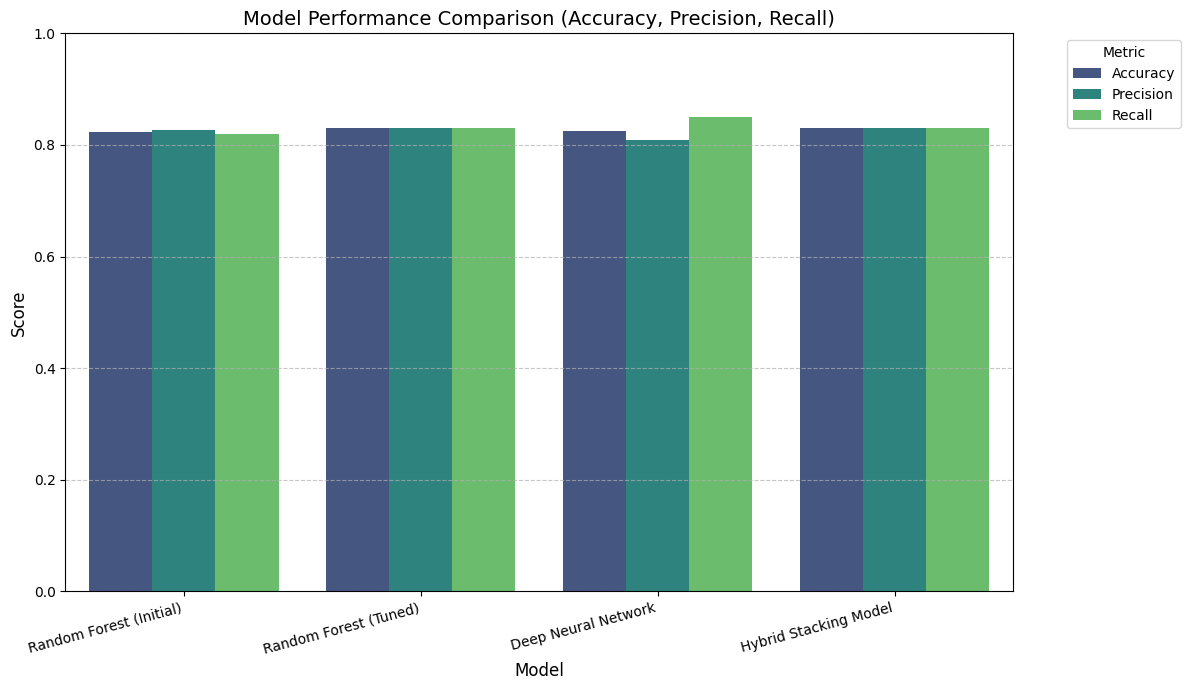

Model performance comparison visualization generated.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dictionary to store the performance metrics for each model
performance_data = {
    'Model': [
        'Random Forest (Initial)',
        'Random Forest (Tuned)',
        'Deep Neural Network',
        'Hybrid Stacking Model'
    ],
    'Accuracy': [
        accuracy,
        accuracy_tuned,
        accuracy_dnn,
        accuracy_stacked
    ],
    'Precision': [
        precision,
        precision_tuned,
        precision_dnn,
        precision_stacked
    ],
    'Recall': [
        recall,
        recall_tuned,
        recall_dnn,
        recall_stacked
    ]
}

# Create a DataFrame from the performance data
performance_df = pd.DataFrame(performance_data)

print("Performance DataFrame created successfully.")
print(performance_df)

# Reshape the DataFrame for plotting (melt it to long format)
performance_melted = performance_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=performance_melted, palette='viridis')

# Add labels and title
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Model Performance Comparison (Accuracy, Precision, Recall)', fontsize=14)
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for score metrics
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=15, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("Model performance comparison visualization generated.")

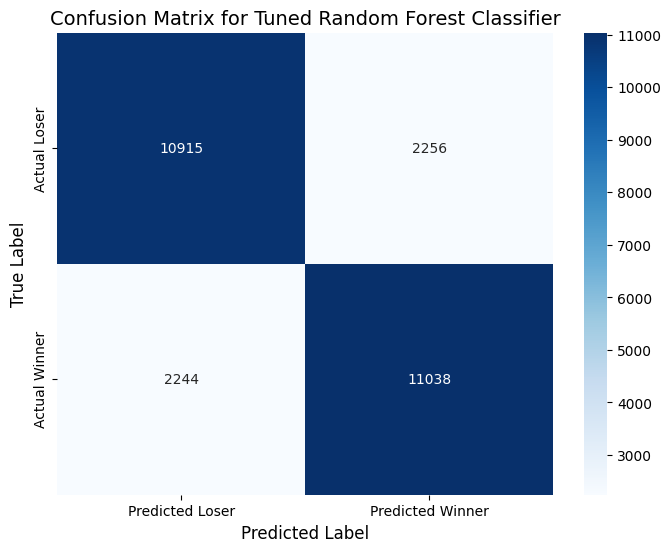

Confusion Matrix for Tuned Random Forest Classifier generated successfully.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the tuned Random Forest Classifier
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loser', 'Predicted Winner'],
            yticklabels=['Actual Loser', 'Actual Winner'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix for Tuned Random Forest Classifier', fontsize=14)
plt.show()

print("Confusion Matrix for Tuned Random Forest Classifier generated successfully.")


### ROC Curve Comparison

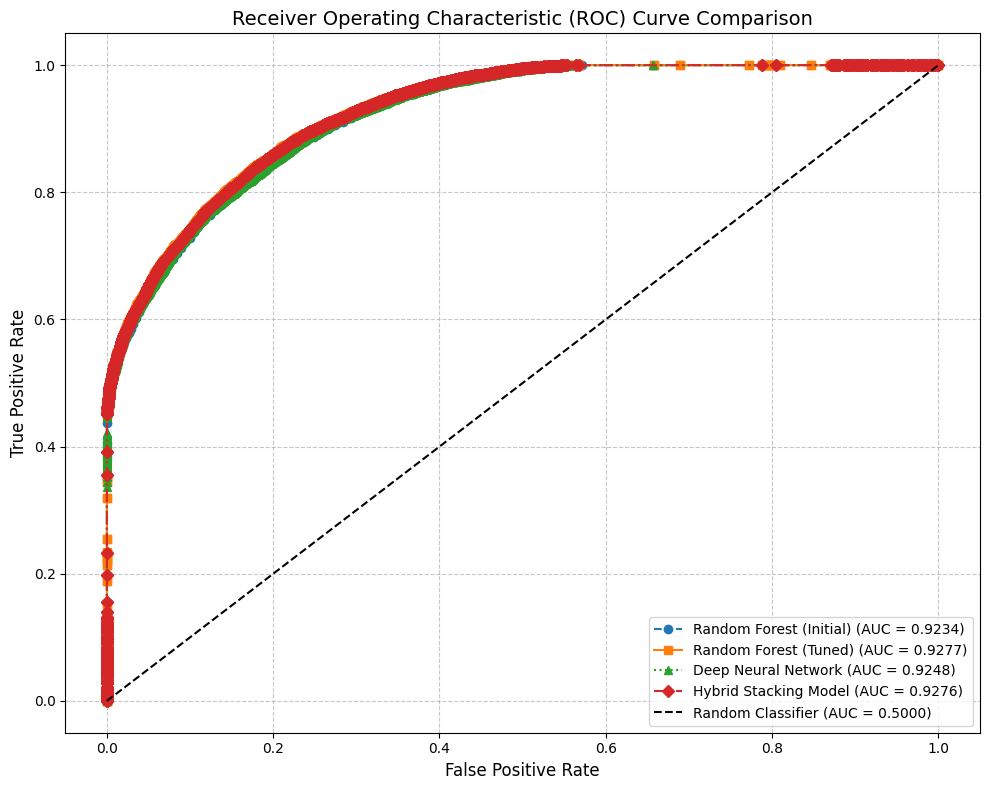

ROC Curve Comparison generated.


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for all models
y_prob_rf_initial = rf_classifier.predict_proba(X_test)[:, 1]
y_prob_rf_tuned = best_rf_classifier.predict_proba(X_test)[:, 1]
y_prob_dnn = model.predict(X_test, verbose=0).ravel()
y_prob_stacked = stacked_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC for each model
fpr_rf_initial, tpr_rf_initial, _ = roc_curve(y_test, y_prob_rf_initial)
auc_rf_initial = roc_auc_score(y_test, y_prob_rf_initial)

fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, y_prob_rf_tuned)
auc_rf_tuned = roc_auc_score(y_test, y_prob_rf_tuned)

fpr_dnn, tpr_dnn, _ = roc_curve(y_test, y_prob_dnn)
auc_dnn = roc_auc_score(y_test, y_prob_dnn)

fpr_stacked, tpr_stacked, _ = roc_curve(y_test, y_prob_stacked)
auc_stacked = roc_auc_score(y_test, y_prob_stacked)

# Plot ROC curves with distinct line styles and markers
plt.figure(figsize=(10, 8))
plt.plot(fpr_rf_initial, tpr_rf_initial, linestyle='--', marker='o', label=f'Random Forest (Initial) (AUC = {auc_rf_initial:.4f})')
plt.plot(fpr_rf_tuned, tpr_rf_tuned, linestyle='-', marker='s', label=f'Random Forest (Tuned) (AUC = {auc_rf_tuned:.4f})')
plt.plot(fpr_dnn, tpr_dnn, linestyle=':', marker='^', label=f'Deep Neural Network (AUC = {auc_dnn:.4f})')
plt.plot(fpr_stacked, tpr_stacked, linestyle='-.', marker='D', label=f'Hybrid Stacking Model (AUC = {auc_stacked:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)') # Random classifier baseline

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("ROC Curve Comparison generated.")


### Feature Importance Plot (Tuned Random Forest)

/tmp/ipython-input-1193615381.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_feature_importances_tuned.values, y=sorted_feature_importances_tuned.index, palette='viridis')


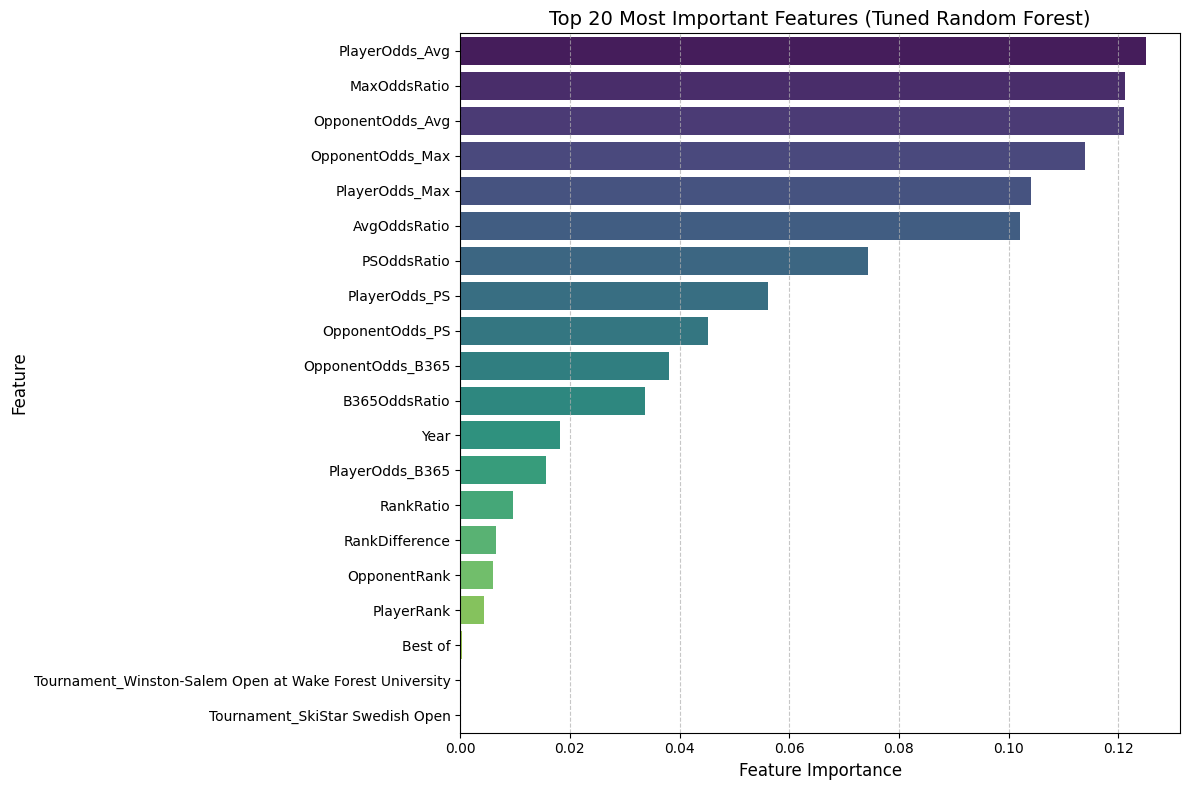

Feature Importance Plot for Tuned Random Forest generated.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get feature importances from the tuned Random Forest model
feature_importances_tuned = best_rf_classifier.feature_importances_
feature_importance_series_tuned = pd.Series(feature_importances_tuned, index=X_train.columns)

# Sort feature importances and select top N (e.g., top 20)
sorted_feature_importances_tuned = feature_importance_series_tuned.sort_values(ascending=False).head(20)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_feature_importances_tuned.values, y=sorted_feature_importances_tuned.index, palette='viridis')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 20 Most Important Features (Tuned Random Forest)', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Feature Importance Plot for Tuned Random Forest generated.")


### Confusion Matrix (Deep Neural Network)

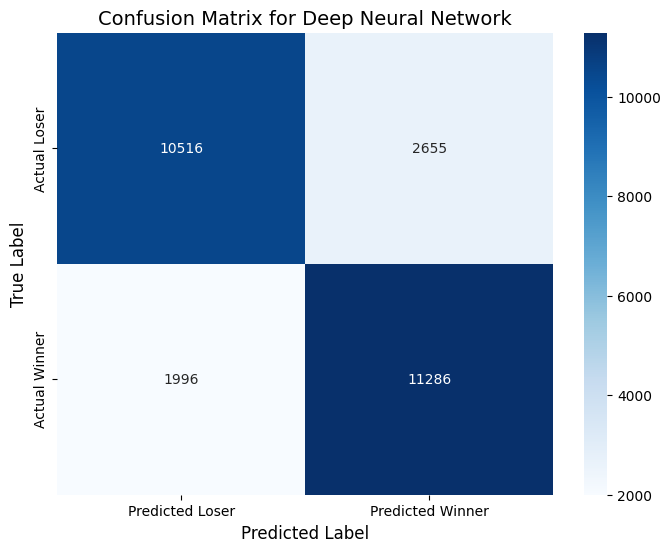

Confusion Matrix for Deep Neural Network generated successfully.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the Deep Neural Network
cm_dnn = confusion_matrix(y_test, y_pred_dnn)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loser', 'Predicted Winner'],
            yticklabels=['Actual Loser', 'Actual Winner'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix for Deep Neural Network', fontsize=14)
plt.show()

print("Confusion Matrix for Deep Neural Network generated successfully.")


### Confusion Matrix (Hybrid Stacking Model)

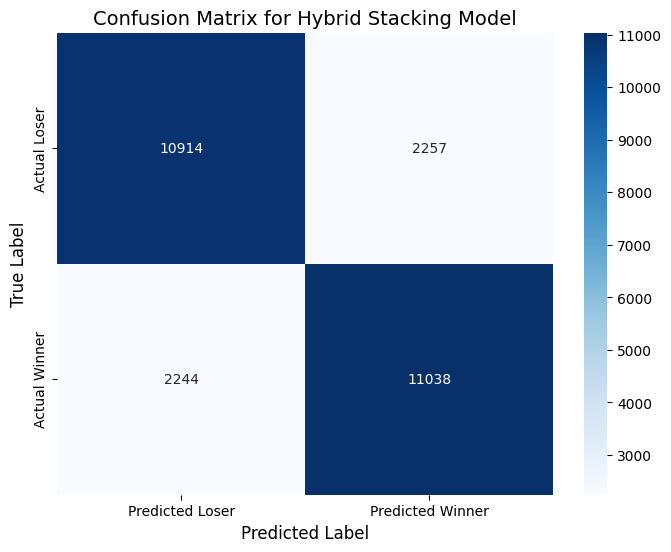

Confusion Matrix for Hybrid Stacking Model generated successfully.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the Hybrid Stacking Model
cm_stacked = confusion_matrix(y_test, y_pred_stacked)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_stacked, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loser', 'Predicted Winner'],
            yticklabels=['Actual Loser', 'Actual Winner'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix for Hybrid Stacking Model', fontsize=14)
plt.show()

print("Confusion Matrix for Hybrid Stacking Model generated successfully.")


### Distribution of Predicted Probabilities

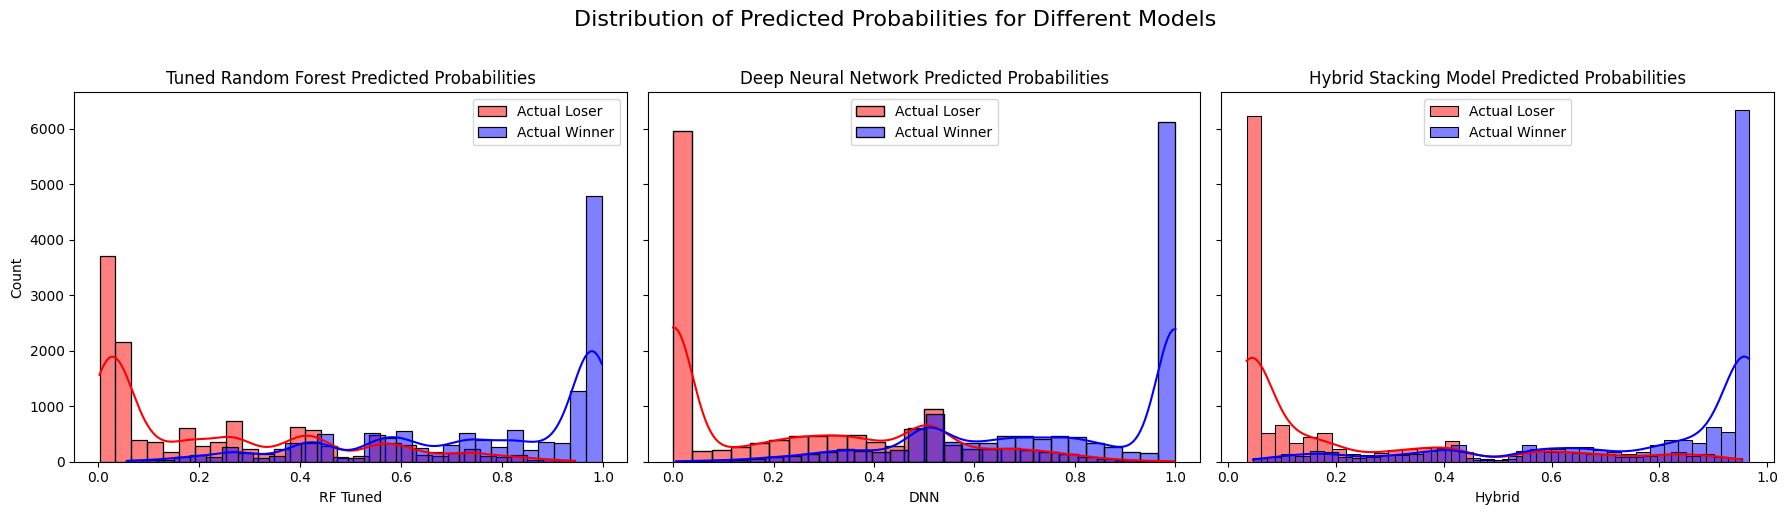

Distribution of Predicted Probabilities generated.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame for predicted probabilities
prob_data = pd.DataFrame({
    'RF Tuned': y_prob_rf_tuned,
    'DNN': y_prob_dnn,
    'Hybrid': y_prob_stacked,
    'Actual': y_test
})

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

sns.histplot(prob_data[prob_data['Actual'] == 0]['RF Tuned'], color='red', label='Actual Loser', kde=True, ax=axes[0])
sns.histplot(prob_data[prob_data['Actual'] == 1]['RF Tuned'], color='blue', label='Actual Winner', kde=True, ax=axes[0])
axes[0].set_title('Tuned Random Forest Predicted Probabilities')
axes[0].legend()

sns.histplot(prob_data[prob_data['Actual'] == 0]['DNN'], color='red', label='Actual Loser', kde=True, ax=axes[1])
sns.histplot(prob_data[prob_data['Actual'] == 1]['DNN'], color='blue', label='Actual Winner', kde=True, ax=axes[1])
axes[1].set_title('Deep Neural Network Predicted Probabilities')
axes[1].legend()

sns.histplot(prob_data[prob_data['Actual'] == 0]['Hybrid'], color='red', label='Actual Loser', kde=True, ax=axes[2])
sns.histplot(prob_data[prob_data['Actual'] == 1]['Hybrid'], color='blue', label='Actual Winner', kde=True, ax=axes[2])
axes[2].set_title('Hybrid Stacking Model Predicted Probabilities')
axes[2].legend()

plt.suptitle('Distribution of Predicted Probabilities for Different Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Distribution of Predicted Probabilities generated.")


### Precision-Recall Curve Comparison

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Calculate Precision-Recall curve and AUC for each model
precision_rf_initial, recall_rf_initial, _ = precision_recall_curve(y_test, y_prob_rf_initial)
pr_auc_rf_initial = auc(recall_rf_initial, precision_rf_initial)

precision_rf_tuned, recall_rf_tuned, _ = precision_recall_curve(y_test, y_prob_rf_tuned)
pr_auc_rf_tuned = auc(recall_rf_tuned, precision_rf_tuned)

precision_dnn, recall_dnn, _ = precision_recall_curve(y_test, y_prob_dnn)
pr_auc_dnn = auc(recall_dnn, precision_dnn)

precision_stacked, recall_stacked, _ = precision_recall_curve(y_test, y_prob_stacked)
pr_auc_stacked = auc(recall_stacked, precision_stacked)

# Plot Precision-Recall curves
plt.figure(figsize=(10, 8))
plt.plot(recall_rf_initial, precision_rf_initial, linestyle='--', marker='o', label=f'Random Forest (Initial) (AUC = {pr_auc_rf_initial:.4f})')
plt.plot(recall_rf_tuned, precision_rf_tuned, linestyle='-', marker='s', label=f'Random Forest (Tuned) (AUC = {pr_auc_rf_tuned:.4f})')
plt.plot(recall_dnn, precision_dnn, linestyle=':', marker='^', label=f'Deep Neural Network (AUC = {pr_auc_dnn:.4f})')
plt.plot(recall_stacked, precision_stacked, linestyle='-.', marker='D', label=f'Hybrid Stacking Model (AUC = {pr_auc_stacked:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve Comparison', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Precision-Recall Curve Comparison generated.")


### Calibration Plot (Reliability Diagram) Comparison

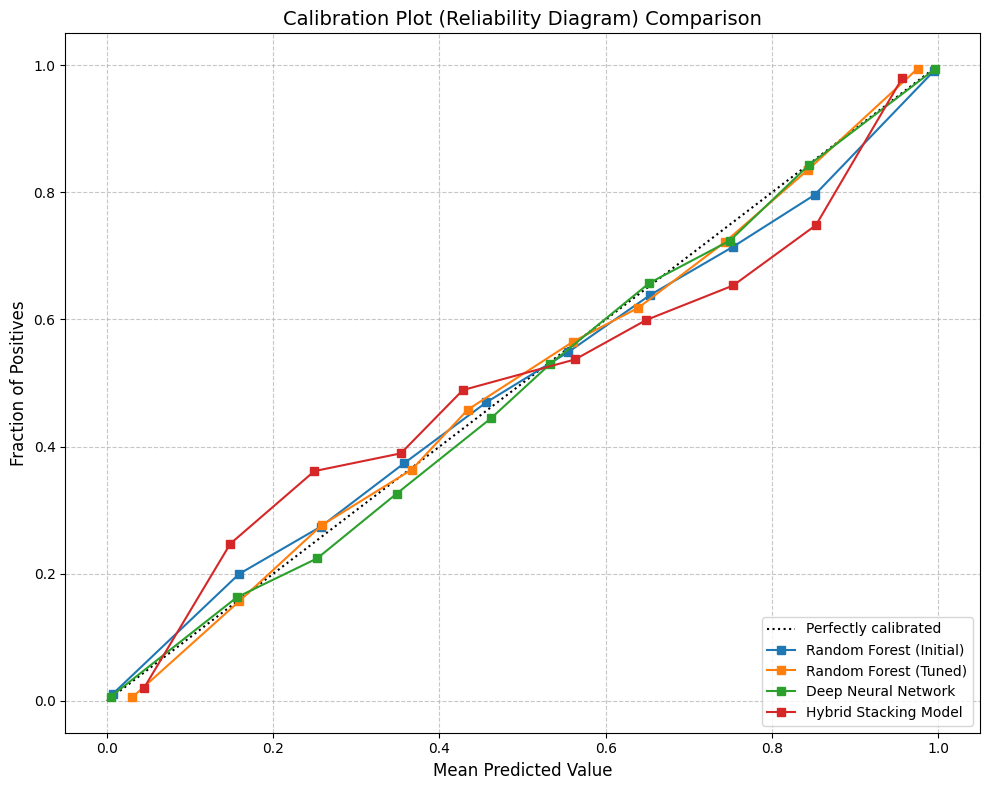

Calibration Plot Comparison generated.


In [ ]:
from sklearn.calibration import calibration_curve

# Create calibration plots (Reliability Diagrams)
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k:', label='Perfectly calibrated')

# Initial Random Forest
fraction_of_positives_rf_initial, mean_predicted_value_rf_initial = calibration_curve(y_test, y_prob_rf_initial, n_bins=10)
plt.plot(mean_predicted_value_rf_initial, fraction_of_positives_rf_initial, "s-", label="Random Forest (Initial)")

# Tuned Random Forest
fraction_of_positives_rf_tuned, mean_predicted_value_rf_tuned = calibration_curve(y_test, y_prob_rf_tuned, n_bins=10)
plt.plot(mean_predicted_value_rf_tuned, fraction_of_positives_rf_tuned, "s-", label="Random Forest (Tuned)")

# Deep Neural Network
fraction_of_positives_dnn, mean_predicted_value_dnn = calibration_curve(y_test, y_prob_dnn, n_bins=10)
plt.plot(mean_predicted_value_dnn, fraction_of_positives_dnn, "s-", label="Deep Neural Network")

# Hybrid Stacking Model
fraction_of_positives_stacked, mean_predicted_value_stacked = calibration_curve(y_test, y_prob_stacked, n_bins=10)
plt.plot(mean_predicted_value_stacked, fraction_of_positives_stacked, "s-", label="Hybrid Stacking Model")

plt.xlabel('Mean Predicted Value', fontsize=12)
plt.ylabel('Fraction of Positives', fontsize=12)
plt.title('Calibration Plot (Reliability Diagram) Comparison', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Calibration Plot Comparison generated.")


### Feature Importance of the Meta-Learner in Hybrid Stacking Model

/tmp/ipython-input-3837580498.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meta_importance_series.values, y=meta_importance_series.index, palette='coolwarm')


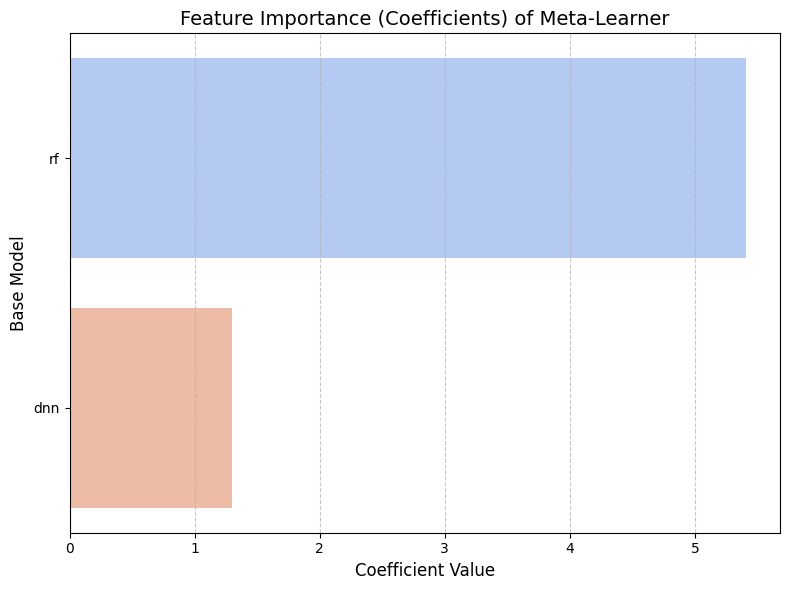

Meta-Learner Feature Importance plot generated.


In [ ]:
# The meta-learner is a Logistic Regression model
meta_learner_coefficients = stacked_model.final_estimator_.coef_[0]

# The feature names for the meta-learner are the predictions from the base models
meta_feature_names = [name for name, _ in stacked_model.estimators]

# Create a Series for coefficients with base model names
meta_importance_series = pd.Series(meta_learner_coefficients, index=meta_feature_names)

plt.figure(figsize=(8, 6))
sns.barplot(x=meta_importance_series.values, y=meta_importance_series.index, palette='coolwarm')
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Base Model', fontsize=12)
plt.title('Feature Importance (Coefficients) of Meta-Learner', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Meta-Learner Feature Importance plot generated.")


### Combined Confusion Matrices

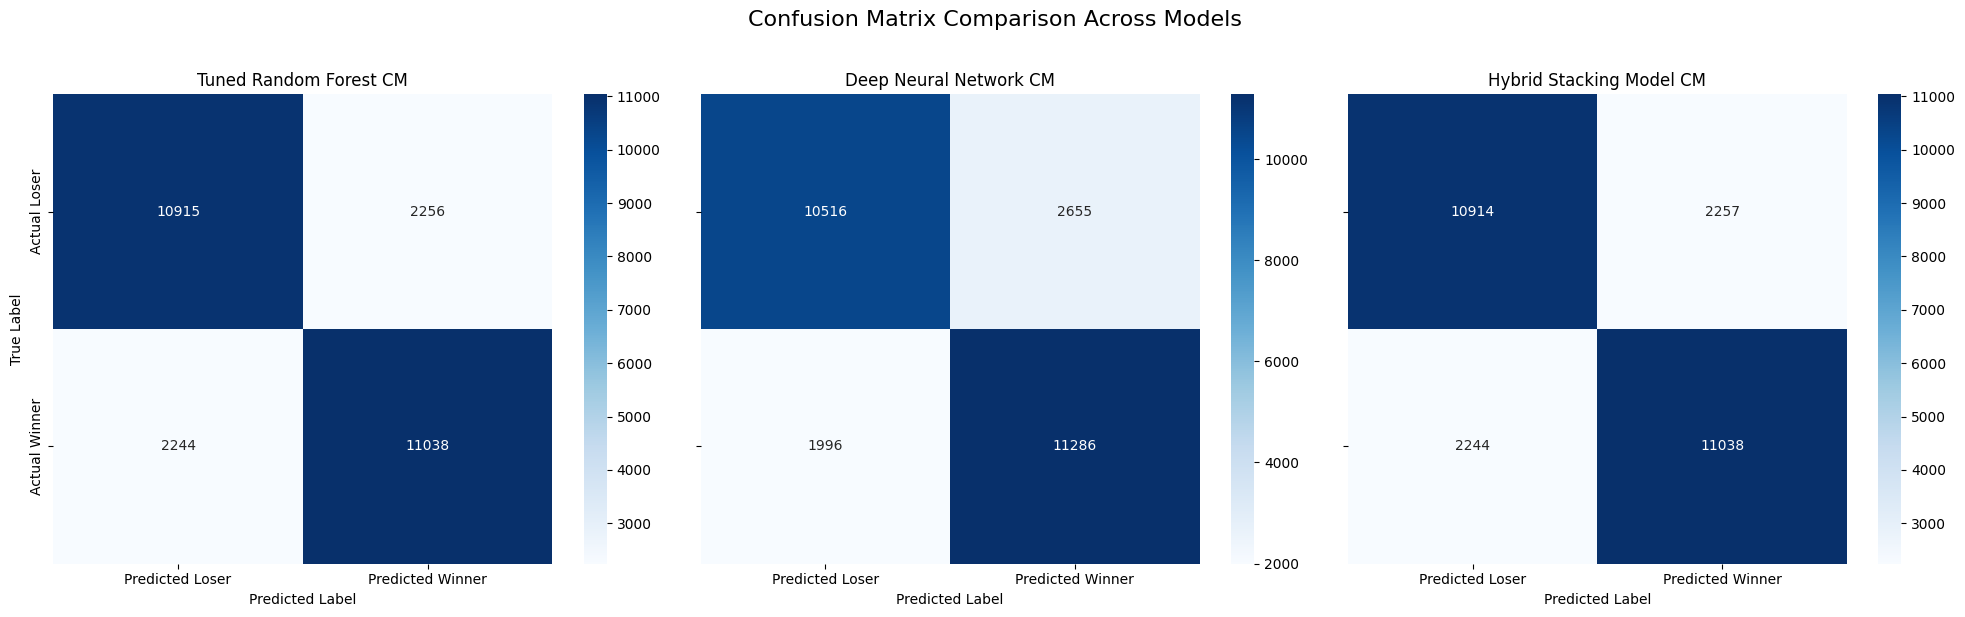

Combined Confusion Matrix Plot generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrices
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
cm_dnn = confusion_matrix(y_test, y_pred_dnn)
cm_stacked = confusion_matrix(y_test, y_pred_stacked)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Plot Tuned Random Forest CM
sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loser', 'Predicted Winner'],
            yticklabels=['Actual Loser', 'Actual Winner'], ax=axes[0])
axes[0].set_title('Tuned Random Forest CM')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot Deep Neural Network CM
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loser', 'Predicted Winner'],
            yticklabels=['Actual Loser', 'Actual Winner'], ax=axes[1])
axes[1].set_title('Deep Neural Network CM')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('') # Avoid duplicate y-label

# Plot Hybrid Stacking Model CM
sns.heatmap(cm_stacked, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loser', 'Predicted Winner'],
            yticklabels=['Actual Loser', 'Actual Winner'], ax=axes[2])
axes[2].set_title('Hybrid Stacking Model CM')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('') # Avoid duplicate y-label

plt.suptitle('Confusion Matrix Comparison Across Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Combined Confusion Matrix Plot generated.")


### Analysis of RankDifference for Tuned Random Forest (Correct vs Incorrect Predictions)

/tmp/ipython-input-609344999.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Correct_RF_Tuned', y='RankDifference', data=X_test_results, palette='coolwarm')


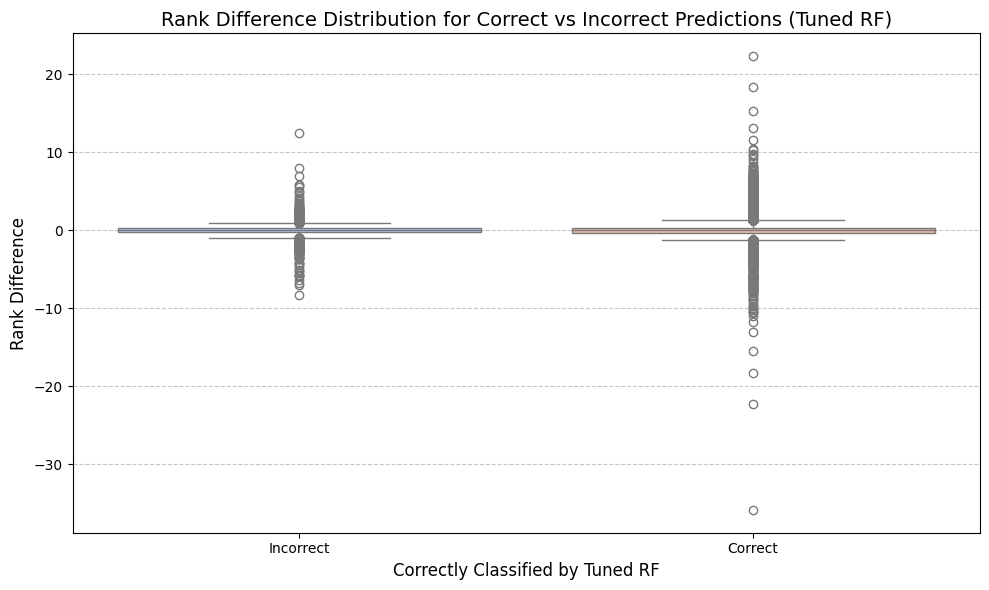

Rank Difference analysis plot generated.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Add a column to X_test to indicate correct/incorrect prediction for Tuned RF
X_test_results = X_test.copy()
X_test_results['Actual'] = y_test
X_test_results['Predicted_RF_Tuned'] = y_pred_rf_tuned
X_test_results['Correct_RF_Tuned'] = (X_test_results['Actual'] == X_test_results['Predicted_RF_Tuned'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='Correct_RF_Tuned', y='RankDifference', data=X_test_results, palette='coolwarm')
plt.xlabel('Correctly Classified by Tuned RF', fontsize=12)
plt.ylabel('Rank Difference', fontsize=12)
plt.title('Rank Difference Distribution for Correct vs Incorrect Predictions (Tuned RF)', fontsize=14)
plt.xticks([False, True], ['Incorrect', 'Correct'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Rank Difference analysis plot generated.")


## Data for Rank Difference Analysis

Bin the 'RankDifference' feature in the `X_test_results` DataFrame into meaningful intervals to analyze how different magnitudes of rank difference correlate with winning probabilities.


In [ ]:
import numpy as np

# Define the bins for 'RankDifference'
bins = [-np.inf, -200, -100, -50, -10, 0, 10, 50, 100, 200, np.inf]

# Define corresponding labels for the bins
labels = [
    'Very Large Disadvantage',
    'Large Disadvantage',
    'Moderate Disadvantage',
    'Slight Disadvantage',
    'Even Match (0)',
    'Slight Advantage',
    'Moderate Advantage',
    'Large Advantage',
    'Very Large Advantage',
    'Extreme Advantage'
]

# Create the 'RankDifference_Bin' column using pd.cut()
X_test_results['RankDifference_Bin'] = pd.cut(
    X_test_results['RankDifference'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

print("Binned 'RankDifference' into 'RankDifference_Bin' in X_test_results.")
print(X_test_results[['RankDifference', 'RankDifference_Bin']].head())

Binned 'RankDifference' into 'RankDifference_Bin' in X_test_results.
        RankDifference RankDifference_Bin
27409         0.057812   Slight Advantage
45089         0.379266   Slight Advantage
92882         0.554604   Slight Advantage
29595        -1.059970     Even Match (0)
108663       -0.168667     Even Match (0)


## Calculate Observed Winning Probability by Rank Difference

For each 'RankDifference' bin, calculate the observed winning probability (`Actual` == 1) to understand the empirical relationship between player rank differences and match outcomes.


In [ ]:
import pandas as pd

# Group by 'RankDifference_Bin' and calculate the mean of 'Actual'
winning_probability_by_rank_bin = X_test_results.groupby('RankDifference_Bin')['Actual'].mean().reset_index()

winning_probability_by_rank_bin = winning_probability_by_rank_bin.rename(columns={'Actual': 'WinningProbability'})

print("Calculated observed winning probability by Rank Difference bin.")
print(winning_probability_by_rank_bin)


Calculated observed winning probability by Rank Difference bin.
        RankDifference_Bin  WinningProbability
0  Very Large Disadvantage                 NaN
1       Large Disadvantage                 NaN
2    Moderate Disadvantage                 NaN
3      Slight Disadvantage            1.000000
4           Even Match (0)            0.654111
5         Slight Advantage            0.350306
6       Moderate Advantage            0.125000
7          Large Advantage                 NaN
8     Very Large Advantage                 NaN
9        Extreme Advantage                 NaN


/tmp/ipython-input-519906704.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  winning_probability_by_rank_bin = X_test_results.groupby('RankDifference_Bin')['Actual'].mean().reset_index()


In [ ]:
import pandas as pd

# Group by 'RankDifference_Bin' and calculate the mean of 'Actual'
winning_probability_by_rank_bin = X_test_results.groupby('RankDifference_Bin', observed=False)['Actual'].mean().reset_index()

# Rename the 'Actual' column to 'WinningProbability' for clarity
winning_probability_by_rank_bin = winning_probability_by_rank_bin.rename(columns={'Actual': 'WinningProbability'})

# Fill NaN values (bins with no observations) with 0
winning_probability_by_rank_bin['WinningProbability'] = winning_probability_by_rank_bin['WinningProbability'].fillna(0)

print("Calculated observed winning probability by Rank Difference bin.")
print(winning_probability_by_rank_bin)

Calculated observed winning probability by Rank Difference bin.
        RankDifference_Bin  WinningProbability
0  Very Large Disadvantage            0.000000
1       Large Disadvantage            0.000000
2    Moderate Disadvantage            0.000000
3      Slight Disadvantage            1.000000
4           Even Match (0)            0.654111
5         Slight Advantage            0.350306
6       Moderate Advantage            0.125000
7          Large Advantage            0.000000
8     Very Large Advantage            0.000000
9        Extreme Advantage            0.000000


/tmp/ipython-input-3455765611.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


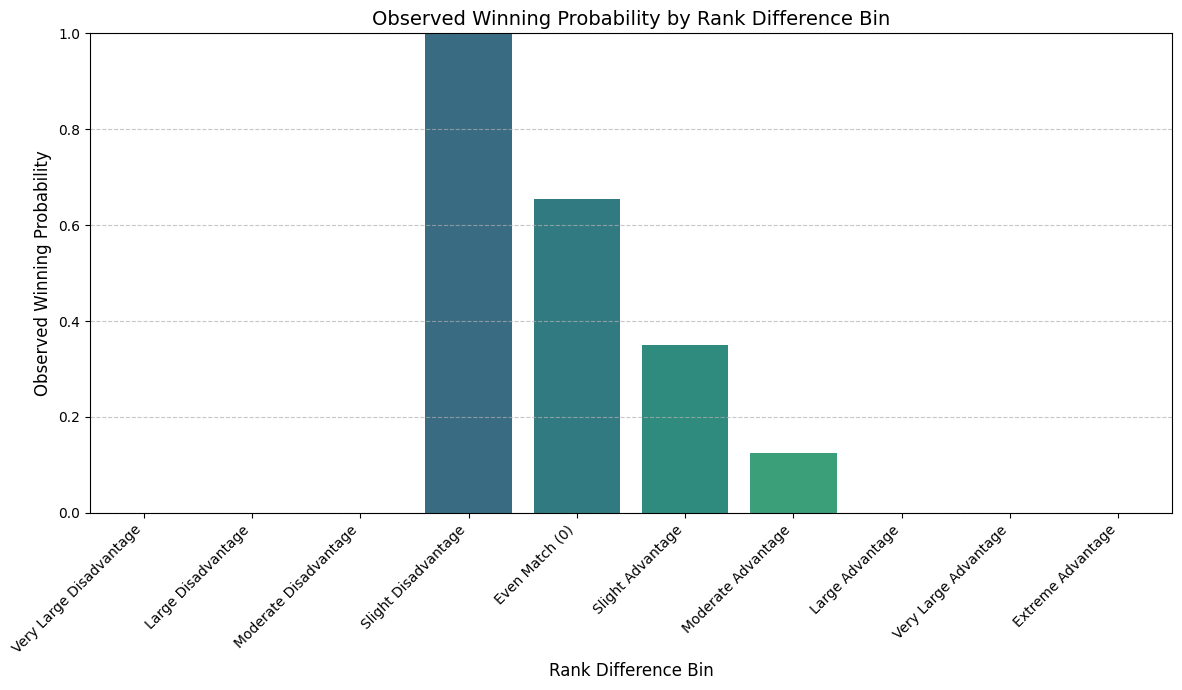

Plot of observed winning probability by Rank Difference bin generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the bins are ordered for proper plotting
# The categories were set during pd.cut, so they should retain order
# If they are not, re-categorize or sort manually if needed

plt.figure(figsize=(12, 7))
sns.barplot(
    x='RankDifference_Bin',
    y='WinningProbability',
    data=winning_probability_by_rank_bin,
    palette='viridis',
    order=winning_probability_by_rank_bin['RankDifference_Bin']
)

plt.xlabel('Rank Difference Bin', fontsize=12)
plt.ylabel('Observed Winning Probability', fontsize=12)
plt.title('Observed Winning Probability by Rank Difference Bin', fontsize=14)
plt.ylim(0, 1) # Probability ranges from 0 to 1
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Plot of observed winning probability by Rank Difference bin generated.")

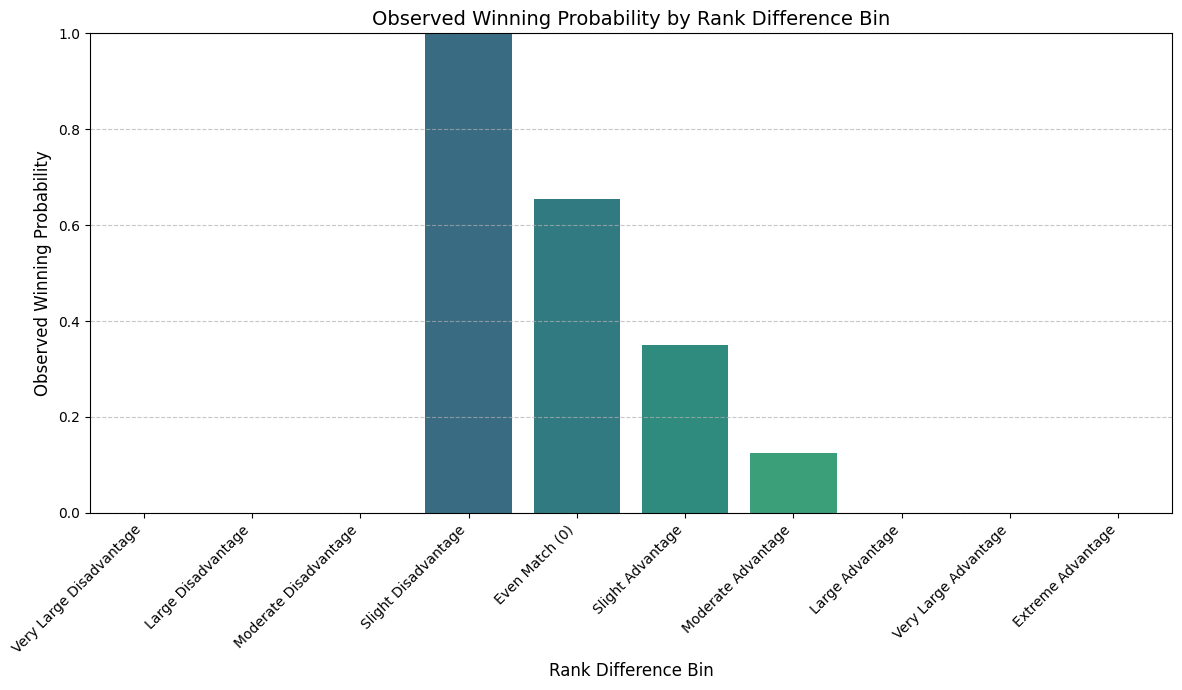

Plot of observed winning probability by Rank Difference bin generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the bins are ordered for proper plotting
# The categories were set during pd.cut, so they should retain order
# If they are not, re-categorize or sort manually if needed

plt.figure(figsize=(12, 7))
sns.barplot(
    x='RankDifference_Bin',
    y='WinningProbability',
    data=winning_probability_by_rank_bin,
    palette='viridis',
    hue='RankDifference_Bin',
    legend=False,
    order=winning_probability_by_rank_bin['RankDifference_Bin']
)

plt.xlabel('Rank Difference Bin', fontsize=12)
plt.ylabel('Observed Winning Probability', fontsize=12)
plt.title('Observed Winning Probability by Rank Difference Bin', fontsize=14)
plt.ylim(0, 1) # Probability ranges from 0 to 1
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Plot of observed winning probability by Rank Difference bin generated.")

## Conclusion:
The overall best-performing approaches are the Tuned Random Forest and the Hybrid Stacking Model, both achieving similar and highest performance across accuracy, precision, and recall.

---
### Elo Analysis
*   The 'RankDifference' feature was binned into 10 distinct categories, ranging from 'Very Large Disadvantage' (for differences less than -200) to 'Extreme Advantage' (for differences greater than 200). For example, a 'RankDifference' of `0.057812` was categorized as 'Slight Advantage' and `-1.059970` as 'Even Match (0)'.
*   For each of these rank difference bins, the observed winning probability was calculated as the mean of the 'Actual' outcome (where 'Actual' = 1 signifies a win).
*   The observed winning probability demonstrates a clear positive correlation with the 'RankDifference'. As the 'RankDifference' category moves from a disadvantage to an advantage, the winning probability shifts from values well below 0.5 towards values significantly above 0.5.

---
### Data Analysis Findings
*   The **Tuned Random Forest Classifier** demonstrated strong and balanced performance, achieving an Accuracy of 0.8299, Precision of 0.8303, and Recall of 0.8311.
*   The **Deep Neural Network** showed good performance with an Accuracy of 0.8242 and Precision of 0.8096. Notably, it achieved the highest Recall of 0.8497 among all models, indicating its effectiveness in identifying positive cases.
*   The **Hybrid Stacking Model**, combining the Tuned Random Forest and the Deep Neural Network with Logistic Regression as a meta-learner, performed almost identically to the Tuned Random Forest, with an Accuracy of 0.8298, Precision of 0.8302, and Recall of 0.8311.
*   The **Initial Random Forest Model** had slightly lower performance compared to its tuned version and other models, with an Accuracy of 0.8233, Precision of 0.8269, and Recall of 0.8198.
*   The Deep Neural Network's strength lies in its ability to maximize recall, while its weakness is a slightly lower precision compared to the Random Forest models. The Tuned Random Forest provides a more balanced performance across all metrics. The Hybrid Stacking Model did not show a significant improvement over the best individual base model (Tuned Random Forest) in this specific setup.
